In [1]:
import numpy as np
import pandas as pd

In [2]:
lambda30 = pd.read_csv(f"/scratch1/smaruj/exploring_parameters/2000_lambda_3.0_results.tsv", sep="\t")
lambda30["lambda"] = [3.0 for i in range(len(lambda30))]

In [3]:
lambda40 = pd.read_csv(f"/scratch1/smaruj/exploring_parameters/2000_lambda_4.0_results.tsv", sep="\t")
lambda40["lambda"] = [4.0 for i in range(len(lambda40))]

In [4]:
lambda50 = pd.read_csv(f"/scratch1/smaruj/exploring_parameters/2000_lambda_5.0_results.tsv", sep="\t")
lambda50["lambda"] = [5.0 for i in range(len(lambda50))]

In [5]:
lambda60 = pd.read_csv(f"/scratch1/smaruj/exploring_parameters/2000_lambda_6.0_results.tsv", sep="\t")
lambda60["lambda"] = [6.0 for i in range(len(lambda60))]

In [6]:
lambda70 = pd.read_csv(f"/scratch1/smaruj/exploring_parameters/2000_lambda_7.0_results.tsv", sep="\t")
lambda70["lambda"] = [7.0 for i in range(len(lambda70))]

In [7]:
lambda80 = pd.read_csv(f"/scratch1/smaruj/exploring_parameters/2000_lambda_8.0_results.tsv", sep="\t")
lambda80["lambda"] = [8.0 for i in range(len(lambda80))]

In [8]:
lambda90 = pd.read_csv(f"/scratch1/smaruj/exploring_parameters/2000_lambda_9.0_results.tsv", sep="\t")
lambda90["lambda"] = [9.0 for i in range(len(lambda90))]

In [9]:
lambda100 = pd.read_csv(f"/scratch1/smaruj/exploring_parameters/2000_lambda_10.0_results.tsv", sep="\t")
lambda100["lambda"] = [10.0 for i in range(len(lambda100))]

In [10]:
lambda110 = pd.read_csv(f"/scratch1/smaruj/exploring_parameters/2000_lambda_11.0_results.tsv", sep="\t")
lambda110["lambda"] = [11.0 for i in range(len(lambda110))]

In [11]:
lambda120 = pd.read_csv(f"/scratch1/smaruj/exploring_parameters/2000_lambda_12.0_results.tsv", sep="\t")
lambda120["lambda"] = [12.0 for i in range(len(lambda120))]

In [12]:
lambda130 = pd.read_csv(f"/scratch1/smaruj/exploring_parameters/2000_lambda_13.0_results.tsv", sep="\t")
lambda130["lambda"] = [13.0 for i in range(len(lambda130))]

In [13]:
lambda140 = pd.read_csv(f"/scratch1/smaruj/exploring_parameters/2000_lambda_14.0_results.tsv", sep="\t")
lambda140["lambda"] = [14.0 for i in range(len(lambda140))]

In [14]:
lambda150 = pd.read_csv(f"/scratch1/smaruj/exploring_parameters/2000_lambda_15.0_results.tsv", sep="\t")
lambda150["lambda"] = [15.0 for i in range(len(lambda150))]

In [17]:
df = pd.concat([lambda30, lambda40, lambda50, lambda60,
                lambda70, lambda80, lambda90, lambda100,
                lambda110, lambda120, lambda130, lambda140, lambda150], ignore_index=True)

In [20]:
len(df[df["SCD"] <= 20.0]) / len(df)

0.06521739130434782

In [21]:
df = df[df["SCD"] > 20.0]

In [22]:
df["URQ_diff"] = df["URQ_result"] - df["URQ_init"]

In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import kruskal

/tmp/SLURM_1198917/ipykernel_2211813/968112340.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='lambda', y=metric, ax=ax, palette="Set2", order=lambda_order)
/tmp/SLURM_1198917/ipykernel_2211813/968112340.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='lambda', y=metric, ax=ax, palette="Set2", order=lambda_order)
/tmp/SLURM_1198917/ipykernel_2211813/968112340.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='lambda', y=metric, ax=ax, palette="Set2", order=lambda_order)
/tmp/SLURM_1198917/ipyker

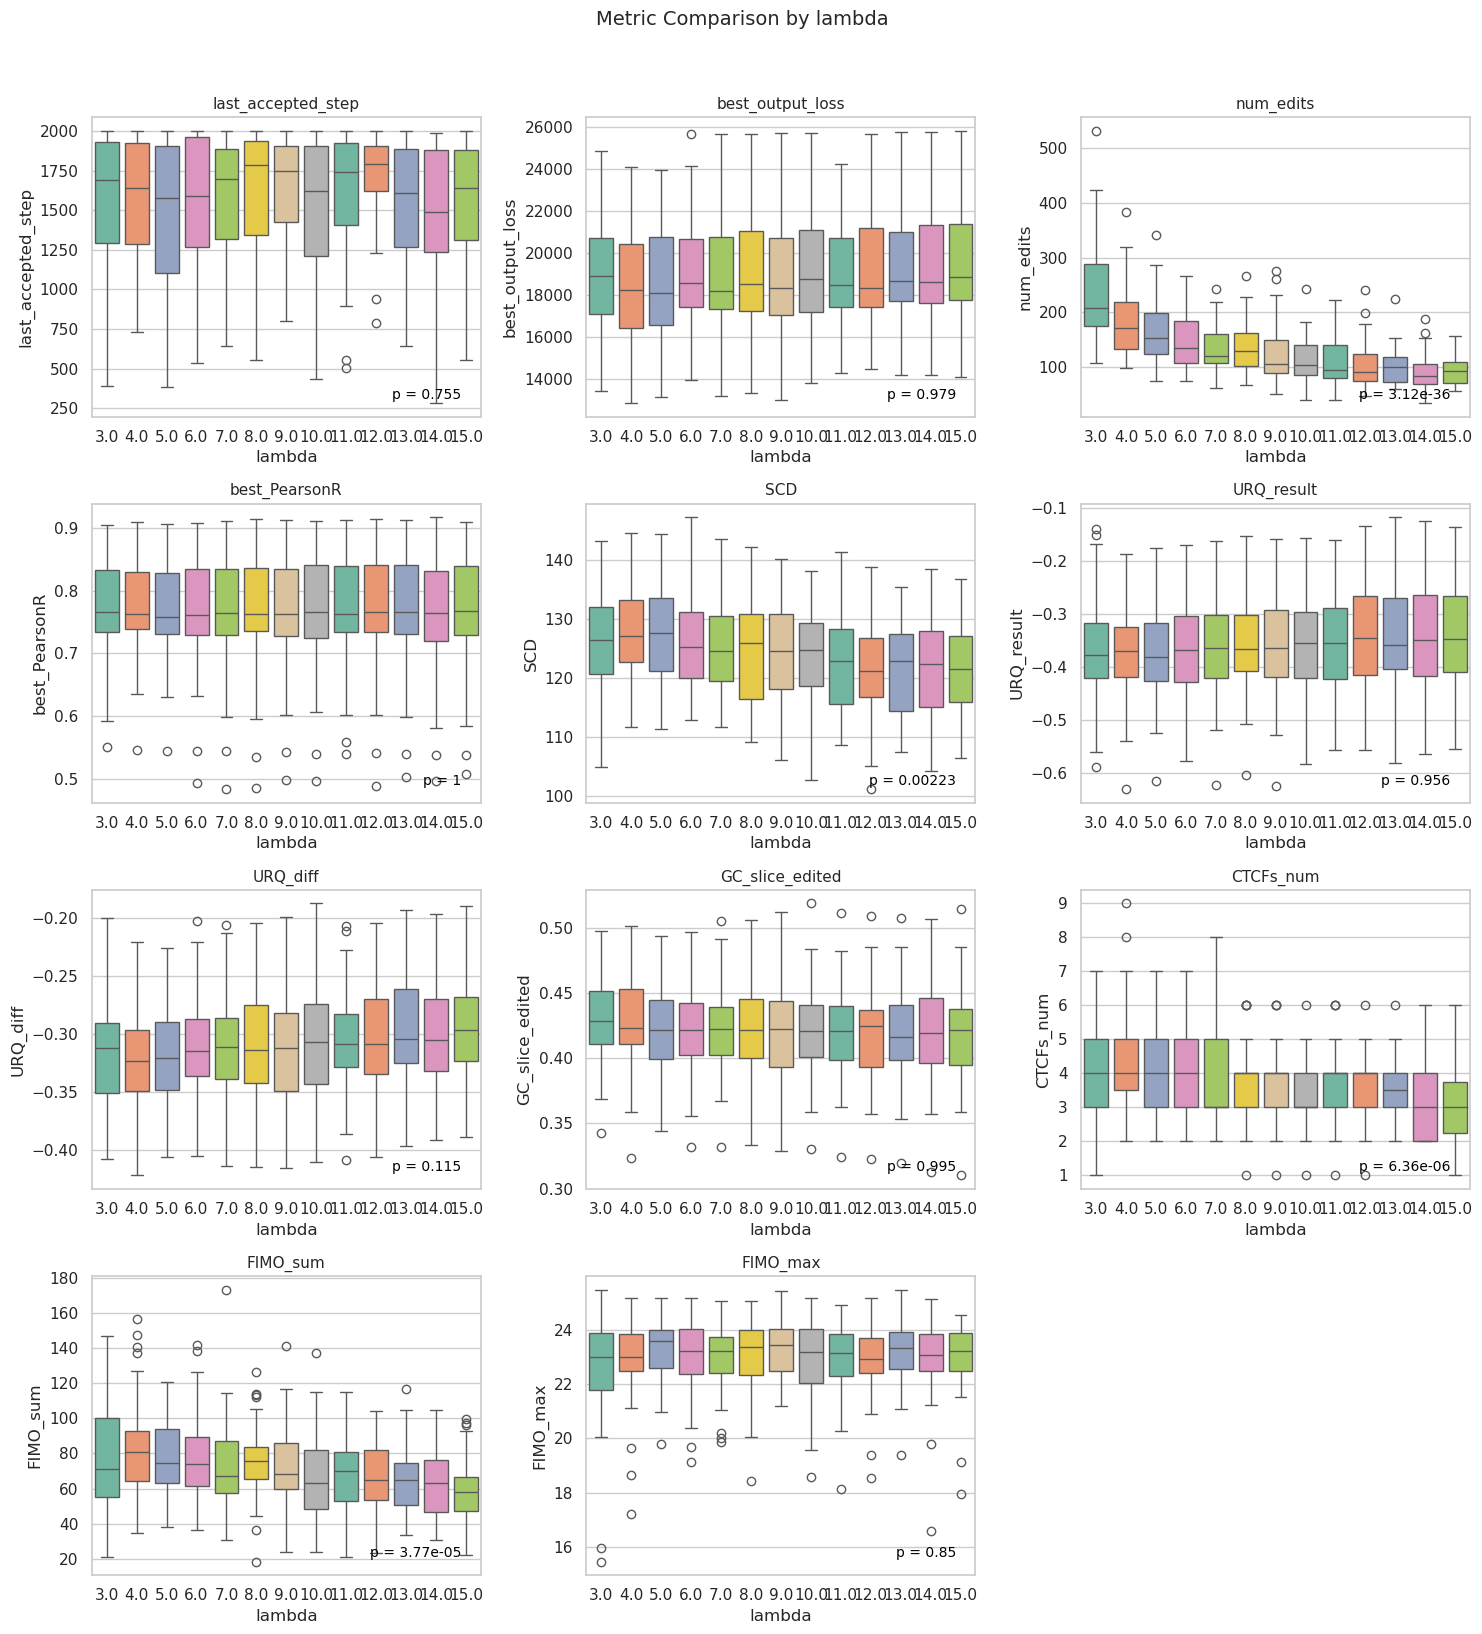

In [24]:
# Define metrics and tau order
metrics = [
    'last_accepted_step', 'best_output_loss', 'num_edits', 'best_PearsonR',
    'SCD', 'URQ_result', 'URQ_diff', 'GC_slice_edited',
    'CTCFs_num', 'FIMO_sum', 'FIMO_max'
]

# Optional: make sure tau is float
df['lambda'] = df['lambda'].astype(float)

# Sort tau values for consistent order in plots
lambda_order = sorted(df['lambda'].unique())

# Set up grid
n_cols = 3
n_rows = -(-len(metrics) // n_cols)

sns.set(style="whitegrid")
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    ax = axes[i]
    sns.boxplot(data=df, x='lambda', y=metric, ax=ax, palette="Set2", order=lambda_order)
    ax.set_title(metric, fontsize=11)
    ax.set_xlabel("lambda")
    ax.set_ylabel(metric)

    # Kruskal-Wallis test across all tau groups
    try:
        groups = [df[df['lambda'] == l][metric].dropna() for l in lambda_order]
        if all(len(g) > 0 for g in groups):
            stat, pval = kruskal(*groups)
            ax.text(0.95, 0.05, f"p = {pval:.3g}", ha='right', va='bottom',
                    transform=ax.transAxes, fontsize=10, color='black')
        else:
            ax.text(0.95, 0.05, "p = N/A", ha='right', va='bottom',
                    transform=ax.transAxes, fontsize=10, color='gray')
    except ValueError:
        ax.text(0.95, 0.05, "p = N/A", ha='right', va='bottom',
                transform=ax.transAxes, fontsize=10, color='gray')

# Hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Metric Comparison by lambda", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


In [25]:
avg_edits_per_lambda = df.groupby('lambda')['num_edits'].mean().reset_index()
print(avg_edits_per_lambda)

    lambda   num_edits
0      3.0  233.826087
1      4.0  185.744186
2      5.0  162.204545
3      6.0  145.613636
4      7.0  133.767442
5      8.0  134.904762
6      9.0  123.255814
7     10.0  113.204545
8     11.0  109.209302
9     12.0  104.069767
10    13.0  101.050000
11    14.0   91.619048
12    15.0   92.690476
